In [1]:
# Leemos los datos de población del censo de 2022 a nivel de hogar y sexo
import pandas as pd

url = "https://github.com/Michaeljo112/estadisticalibro/releases/download/popec22/popec22.parquet"

df = pd.read_parquet(url)

df.head()

,I01,I02,I03,I04,I05,I10,INH,P00,P01,P02,P03
500000,1,1,67,1,1,4,1,4,3,2,26
500001,1,1,67,1,1,4,1,5,5,1,32
500002,1,1,67,1,1,4,1,6,6,2,2
500003,1,1,67,1,1,4,1,7,9,2,19
500004,1,1,67,1,1,5,1,1,1,1,70


In [2]:
# Diccionario de columnas
"""
I01 Provincia
I02 Identificador de Cantón
I03 Identificador de Parroquia
I04 Zona
I05 Sector
I10 Número de vivienda
INH Número de hogar
P00 Número de persona
P01 Parentesco o relación con el representante del hogar
P02 Sexo al nacer
P03 Años cumplidos
"""

excluir = ['P00','P01','P02','P03']

agrupacion = [c for c in df.columns if c not in excluir]

# Al obtener el número máximo del número de persona obtendremos la cantidad de personas del hogar
resumen = (
    df.groupby(agrupacion)
      .agg(numpersonas=('P00','max'))
      .reset_index()
)

In [3]:
# Por alguna razón, el INEC en su ficha metodológica: https://www.censoecuador.gob.ec/wp-content/uploads/2024/02/1.Ficha_Met_Promedio_de_personas_por_hogar.pdf
# Excluye hogar que están clasificados con el número 0. Así que se respetó el filtro
resumen = resumen[resumen['INH']>0]

In [4]:
# Ver un conteo de la cantdiad de personas en el hogar
resumen['numpersonas'].value_counts().sort_index()

,count
numpersonas,
1,314250
2,431560
3,536947
4,633787
5,451793
6,224034
7,100970
8,45275
9,21191


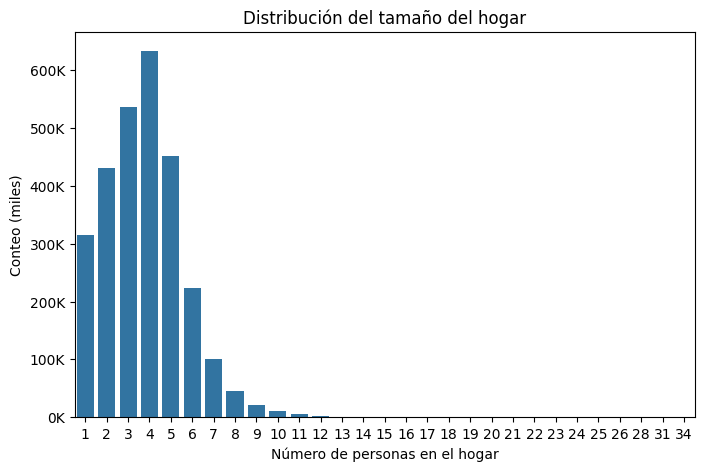

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

freq = resumen['numpersonas'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=freq.index,
    y=freq.values
)

plt.xlabel("Número de personas en el hogar")
plt.ylabel("Conteo (miles)")
plt.title("Distribución del tamaño del hogar")

# Formatear eje Y en miles
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K')
)

plt.show()

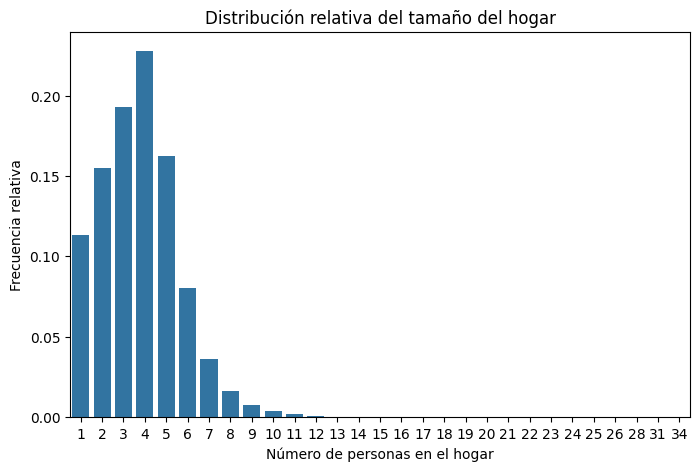

In [6]:
freq_rel = resumen['numpersonas'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=freq_rel.index,
    y=freq_rel.values
)

plt.xlabel("Número de personas en el hogar")
plt.ylabel("Frecuencia relativa")
plt.title("Distribución relativa del tamaño del hogar")

plt.show()